# 4. Diversity Analysis (Alpha & Beta)
## Import data & packages

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy.stats import shapiro, kruskal, f_oneway
  
%matplotlib inline

In [4]:
# 2 - Set working directory
os.chdir("/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/")

# Verify that your wroking directory is the overall project folder (.../MicrobiomeAnalysis_TummyTribe)
print("Current working directory:", os.getcwd())

Current working directory: /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe


In [5]:
# 3 - Data directory for the raw data
data_dir = "data/raw"
processed_data_dir = "data/processed-self_trained"

# 1. Data exploration: look at feature table

In [6]:
data = q2.Artifact.load(f'{processed_data_dir}/dada2_table_140.qza').view(pd.DataFrame)

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
data.head()

,35ffcc3b809d667286737d79670b8de5,d46e2205f0c6ecf67b51f83d111c509c,2c982937754e6321f861027032db80f7,99deb3c5ecb022ec05609ebd1112a557,fd44d4cb468fd7dc9b3227867714ed87,2c5e87b291147c04e1b8d1c808b1aee0,c24e0e391aa836b5eae25567c7eb89ee,9908fffab7ed4f3bec44cda2f5084d49,315ca0a729f126b941ba111a16d4d97a,945184b6386c192c0066e0a98a154780,...,047e632f48dce0de760ec817bdcbef3e,9240c90b3b8e7c00ab05ab4284d51e1c,2154f4860ab30f41e269ba812fdb520a,d503775d72a3df4eff888aadb3114876,e2e62e3197dc381ae908972d6864dc97,69b1cad8580dde56e8c903f9da62a4db,d68aa31298dba81c40c62c43152b241e,6240d7fb191acfaffb50f82175bd171d,4e662d7ba9c81bbf9360fb3bb6a17098,9f74caa39117dbba785390a13274ac21
SRR8115637,13319.0,10758.0,0.0,0.0,0.0,0.0,190.0,1896.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115646,2381.0,489.0,0.0,4951.0,0.0,868.0,1050.0,0.0,8988.0,388.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115666,373.0,1096.0,0.0,9573.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115682,5969.0,332.0,0.0,0.0,0.0,37.0,203.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115685,7051.0,0.0,0.0,0.0,0.0,0.0,221.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Plot the distribution of 15 samples to see if data is normally distributed seaborn's violin plot:

In [9]:
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

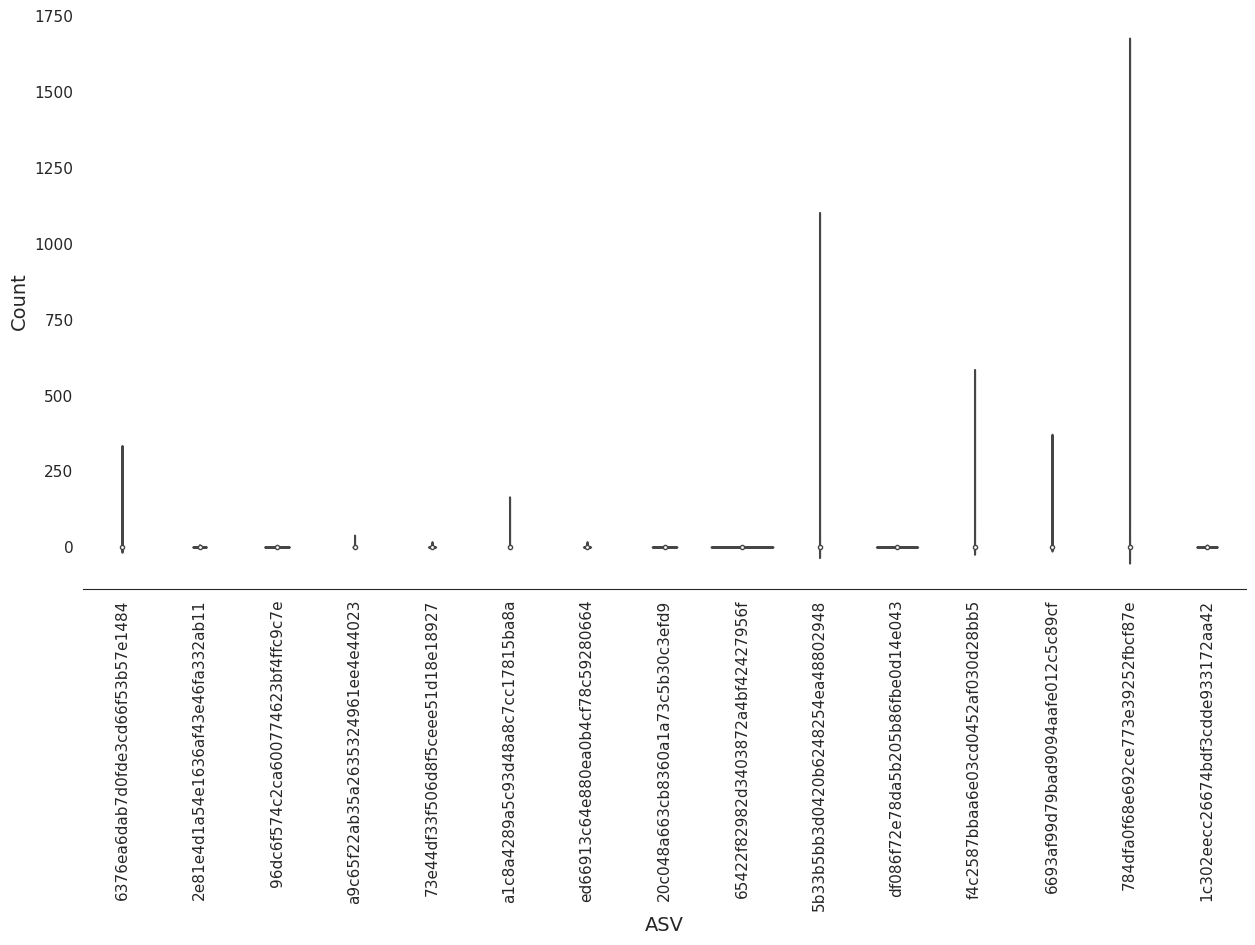

In [10]:
with sns.axes_style('white'), sns.color_palette('Set1'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

From this we can suspect that the data is not normally distributed. We can additionally check this by statistically testing for normality. 

In [11]:
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [12]:
results_df

,p,is_normal
35ffcc3b809d667286737d79670b8de5,6.698205e-33,False
d46e2205f0c6ecf67b51f83d111c509c,1.584342e-32,False
2c982937754e6321f861027032db80f7,3.676114e-33,False
99deb3c5ecb022ec05609ebd1112a557,3.736915e-32,False
fd44d4cb468fd7dc9b3227867714ed87,3.850868e-34,False
...,...,...
69b1cad8580dde56e8c903f9da62a4db,7.024117e-39,False
d68aa31298dba81c40c62c43152b241e,7.024117e-39,False
6240d7fb191acfaffb50f82175bd171d,7.024117e-39,False
4e662d7ba9c81bbf9360fb3bb6a17098,7.024117e-39,False


In [13]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

Number of ASVs with normal distribution: 0


# 2. ANCOM – Delivery Mode

In [15]:
! qiime feature-table filter-features \
    --i-table $processed_data_dir/dada2_table_140.qza \
    --p-min-frequency 25 \
    --p-min-samples 4 \
    --o-filtered-table $processed_data_dir/table_abund_140.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: data/processed-self_trained/table_abund_140.qza


In [16]:
! qiime feature-table filter-samples \
    --i-table $processed_data_dir/table_abund_140.qza \
    --m-metadata-file $data_dir/metadata.tsv \
    --p-where "[delivery_mode]='vaginal' or [delivery_mode]='cesarean'" \
    --o-filtered-table $data_dir/table_abund_deliverymode.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: data/raw/table_abund_deliverymode.qza


In [17]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_deliverymode.qza \
    --m-metadata-file $data_dir/metadata.tsv \
    --p-formula delivery_mode \
    --o-differentials $data_dir/ancombc_deliverymode_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_deliverymode_differentials.qza \
    --o-visualization $data_dir/ancombc_deliverymode_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_deliverymode_differentials.qza \
    --o-visualization $data_dir/ancombc_deliverymode_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: data/raw/ancombc_deliverymode_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: data/raw/ancombc_deliverymode_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pk

In [18]:
Visualization.load(f"{data_dir}/ancombc_deliverymode_da_barplot.qzv")

<visualization: Visualization uuid: 4365b4f3-30fa-4463-b01c-037595bbf921>

In [19]:
Visualization.load(f"{data_dir}/ancombc_deliverymode_results.qzv")

<visualization: Visualization uuid: b2aadd2b-0770-4a0c-a35e-66360d5b7a8f>